[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


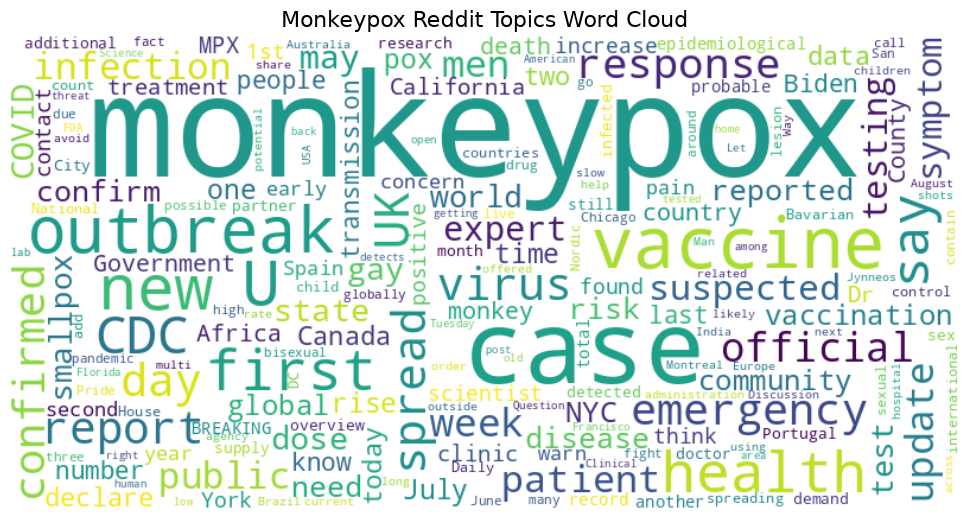

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords


df = pd.read_csv("reddit_monkeypox.csv") 

# Combine relevant text columns (e.g., 'title' or 'selftext') into a single string
# Check column names: df.columns
text = " ".join(review for review in df['title'].dropna().astype(str))

# 2. Apply Stopwords
# Standard WordCloud stopwords combined with NLTK English stopwords
custom_stopwords = set(STOPWORDS)
try:
    nltk.download('stopwords')
    custom_stopwords.update(stopwords.words('english'))
except Exception as e:
    pass

# Add domain-specific stopwords if necessary (e.g., filler words, URLs, etc.)
custom_stopwords.update(["https", "http", "com", "reddit", "amp"])

# Generate Word Cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    stopwords=custom_stopwords, 
    max_words=200, 
    collocations=False
).generate(text)

# Plot Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Monkeypox Reddit Topics Word Cloud", fontsize=16)
plt.tight_layout(pad=0)
plt.show()